In [ ]:
!pip install pytesseract
!apt install tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [ ]:
import cv2
import pytesseract
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
uploaded = files.upload()

Saving Book_3.png to Book_3 (6).png
Saving Book_1.png to Book_1 (30).png
Saving Book_2.png to Book_2 (34).png


In [ ]:
# Função para verificar se há "A" maiúsculo na imagem
def tem_A_maiusculo(img):
    # Converte para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Aplica uma leve binarização para melhorar o OCR
    _, bin_img = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

    # Usa o OCR para extrair o texto
    texto = pytesseract.image_to_string(bin_img, config='--psm 6')
    texto = texto.strip()

    # Verifica se existe "A" maiúsculo
    resultado = 'A' in texto

    return resultado, bin_img  # <-- Retorna dois valores agora!

In [ ]:
# Lista para guardar os resultados
resultados = {}

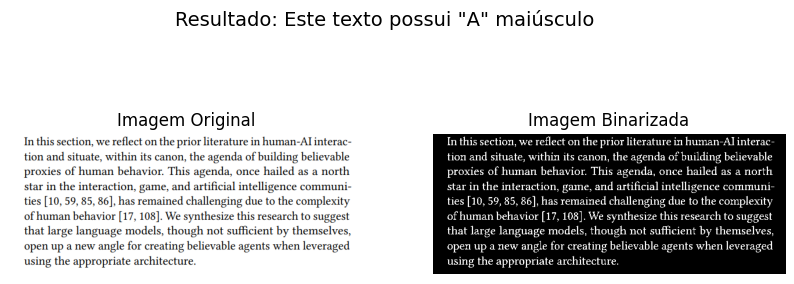

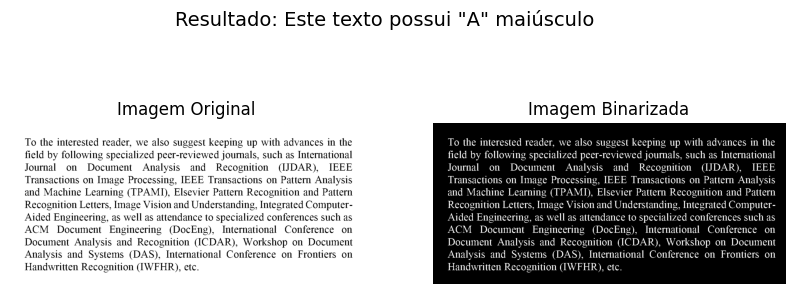

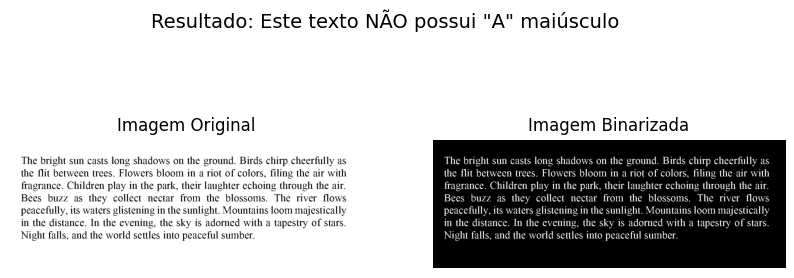

    Nome da Imagem                            Resultado
0   Book_3 (6).png      Este texto possui "A" maiúsculo
1  Book_1 (30).png      Este texto possui "A" maiúsculo
2  Book_2 (34).png  Este texto NÃO possui "A" maiúsculo


In [ ]:
for filename in uploaded.keys():
    # Carrega a imagem
    img = cv2.imread(filename)
    if img is None:
        resultados[filename] = 'Erro ao carregar'
        continue

    # Aplica a detecção (aqui captura resultado E imagem binarizada)
    a_detectado, bin_img = tem_A_maiusculo(img)

    # Guarda o resultado
    resultados[filename] = 'Este texto possui "A" maiúsculo' if a_detectado else 'Este texto NÃO possui "A" maiúsculo'

    # Plotagem
    plt.figure(figsize=(10,4))

    # Original
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Imagem Original')
    plt.axis('off')

    # Binarizada (agora corretamente a da imagem atual!)
    plt.subplot(1, 2, 2)
    plt.imshow(bin_img, cmap='gray')
    plt.title('Imagem Binarizada')
    plt.axis('off')

    plt.suptitle(f'Resultado: {resultados[filename]}', fontsize=14)
    plt.show()

# Cria um DataFrame a partir do dicionário de resultados
df_resultados = pd.DataFrame(list(resultados.items()), columns=['Nome da Imagem', 'Resultado'])

# Mostra o DataFrame
print(df_resultados)